# Exoplanet Spectra × CUDA for Machine Learning — Google Colab Notebook

This notebook maps the later lecture slides onto **real public exoplanet-related spectra data**.

## What it shows
- host ↔ device execution on real spectra
- 1D / 2D / 3D indexing ideas
- masks, branch-style logic, and divergence intuition
- reductions on real spectra
- GEMM on spectral design matrices
- softmax and attention on spectral windows
- synchronization and profiling in PyTorch

## Data source path
The notebook first tries to download a **public JWST/HST exoplanet-related spectrum** from **MAST** using `astroquery.mast`.
Targets tried by default:
- `WASP-96 b`
- `WASP-39 b`

If the product inventory changes, the notebook includes a manual fallback for uploading a FITS or CSV spectrum.

In [ ]:
import os, math, time, statistics, warnings
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
except Exception:
    !pip -q install torch
    import torch

try:
    from astroquery.mast import Observations
    from astropy.io import fits
    from astropy.table import Table
except Exception:
    !pip -q install astroquery astropy
    from astroquery.mast import Observations
    from astropy.io import fits
    from astropy.table import Table

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Switch Colab runtime to GPU for the CUDA parts.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.2 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
def benchmark(fn, warmup=5, iters=20, label="benchmark"):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    for _ in range(warmup):
        fn()
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        out = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1e3)

    print(f"{label}: mean={statistics.mean(times):.3f} ms | median={statistics.median(times):.3f} ms | min={min(times):.3f} ms")
    return out, times

## 1. Retrieve a real public spectrum from MAST

The search is intentionally exploratory:
- query by target name,
- keep public products,
- prefer FITS files with subgroup names such as `X1D`, `C1D`, `SPEC`, or text mentioning spectrum.

If the automatic search fails, use the manual fallback section later.

In [ ]:
TARGET_CANDIDATES = ["WASP-96 b", "WASP-39 b", "WASP-39", "WASP-96"]
DOWNLOAD_DIR = "mast_spectra"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

def find_public_spectral_product(targets: List[str]):
    for target in targets:
        print(f"\n=== Searching target: {target} ===")
        try:
            obs = Observations.query_object(target, radius="0.02 deg")
        except Exception as e:
            print("Query failed:", e)
            continue

        if len(obs) == 0:
            print("No observations found.")
            continue

        obs_df = obs.to_pandas()
        keep = obs_df.copy()

        if "obs_collection" in keep.columns:
            jw = keep[keep["obs_collection"].astype(str).str.contains("JWST|HST", case=False, na=False)]
            if len(jw) > 0:
                keep = jw

        if "dataRights" in keep.columns:
            pub = keep[keep["dataRights"].astype(str).str.contains("PUBLIC", case=False, na=False)]
            if len(pub) > 0:
                keep = pub

        print("Candidate observations:", len(keep))
        if len(keep) == 0:
            continue

        for obsid in keep["obsid"].head(8).tolist():
            try:
                products = Observations.get_product_list(obsid)
                pdf = products.to_pandas()
            except Exception as e:
                print("Product retrieval failed:", e)
                continue

            if "dataRights" in pdf.columns:
                pubp = pdf[pdf["dataRights"].astype(str).str.contains("PUBLIC", case=False, na=False)]
                if len(pubp) > 0:
                    pdf = pubp

            if "productFilename" in pdf.columns:
                pdf = pdf[pdf["productFilename"].astype(str).str.lower().str.endswith(".fits")]

            pref_cols = [c for c in ["productSubGroupDescription", "description", "productFilename"] if c in pdf.columns]
            if pref_cols:
                mask = pd.Series(False, index=pdf.index)
                for c in pref_cols:
                    mask = mask | pdf[c].astype(str).str.contains("X1D|C1D|S1D|SPEC|spectrum|x1d", case=False, na=False)
                better = pdf[mask]
                if len(better) > 0:
                    pdf = better

            if len(pdf) == 0:
                continue

            print(f"Selected target candidate: {target}")
            cols = [c for c in ["obs_id", "obs_collection", "productFilename", "productSubGroupDescription", "description", "calib_level"] if c in pdf.columns]
            print(pdf[cols].head(10).to_string(index=False))
            return target, Table.from_pandas(pdf.head(1))

    return None, None

selected_target, selected_products = find_public_spectral_product(TARGET_CANDIDATES)
print("\nSelected target:", selected_target)
print("Found product:", selected_products is not None)


=== Searching target: WASP-96 b ===
Candidate observations: 352
Selected target candidate: WASP-96 b
                                            obs_id obs_collection                                                 productFilename productSubGroupDescription                                                     description  calib_level
              jw02734002001_04101_00001-seg003_nis           JWST               jw02734002001_04101_00001-seg003_nis_x1dints.fits                    X1DINTS exposure/target (L2b/L3): 1D extracted spectrum per integration            2
              jw02734002001_04101_00001-seg002_nis           JWST               jw02734002001_04101_00001-seg002_nis_x1dints.fits                    X1DINTS exposure/target (L2b/L3): 1D extracted spectrum per integration            2
              jw02734002001_04101_00001-seg001_nis           JWST               jw02734002001_04101_00001-seg001_nis_x1dints.fits                    X1DINTS exposure/target (L2b/L3): 1D extracted 

In [ ]:
downloaded_files = []

if selected_products is not None:
    try:
        manifest = Observations.download_products(
            selected_products,
            download_dir=DOWNLOAD_DIR,
            mrp_only=False
        )
        print(manifest)
        if hasattr(manifest, "to_pandas"):
            dm = manifest.to_pandas()
            if "Local Path" in dm.columns:
                downloaded_files = [p for p in dm["Local Path"].tolist() if isinstance(p, str) and os.path.exists(p)]
    except Exception as e:
        print("Download failed:", e)

print("Downloaded files:")
for p in downloaded_files:
    print(" -", p)

if len(downloaded_files) == 0:
    print("No automatic file download yet. Use the manual fallback if needed.")

                                                      Local Path                                                      ...
--------------------------------------------------------------------------------------------------------------------- ...
mast_spectra/mastDownload/JWST/jw02734002001_04101_00001-seg003_nis/jw02734002001_04101_00001-seg003_nis_x1dints.fits ...
Downloaded files:
 - mast_spectra/mastDownload/JWST/jw02734002001_04101_00001-seg003_nis/jw02734002001_04101_00001-seg003_nis_x1dints.fits


In [ ]:
def inspect_fits_columns(path):
    with fits.open(path) as hdul:
        hdul.info()
        for i, hdu in enumerate(hdul):
            if hasattr(hdu, "columns") and hdu.columns is not None:
                print(f"\nHDU {i} columns:")
                print(hdu.columns)

def load_spectrum_from_fits(path):
    with fits.open(path) as hdul:
        for hdu in hdul:
            if not hasattr(hdu, "data") or hdu.data is None:
                continue
            data = hdu.data
            try:
                names = list(data.names)
            except Exception:
                continue

            wave_candidates = [n for n in names if n.lower() in ["wavelength", "wave", "lambda", "wl"]]
            flux_candidates = [n for n in names if n.lower() in ["flux", "f_lambda", "flam", "depth", "transit_depth", "fluxdensity"]]
            err_candidates = [n for n in names if "err" in n.lower() or "unc" in n.lower()]

            if len(wave_candidates) > 0 and len(flux_candidates) > 0:
                w = np.array(data[wave_candidates[0]], dtype=float)
                f = np.array(data[flux_candidates[0]], dtype=float)
                e = np.array(data[err_candidates[0]], dtype=float) if len(err_candidates) > 0 else None
                return w, f, e, names

    raise ValueError("Could not automatically identify wavelength/flux columns.")

spectrum = None

if len(downloaded_files) > 0:
    fits_path = downloaded_files[0]
    try:
        spectrum = load_spectrum_from_fits(fits_path)
        print("Loaded spectrum automatically from:", fits_path)
    except Exception as e:
        print("Automatic FITS read failed:", e)
        print("\nInspect the FITS structure below and adapt the loader if needed:")
        inspect_fits_columns(fits_path)

Loaded spectrum automatically from: mast_spectra/mastDownload/JWST/jw02734002001_04101_00001-seg003_nis/jw02734002001_04101_00001-seg003_nis_x1dints.fits


### Manual fallback (optional)

If the automatic MAST query or FITS reader did not give a usable 1D spectrum, upload a CSV or FITS here and edit the column names if needed.

In [ ]:
# OPTIONAL MANUAL FALLBACK
# from google.colab import files
# uploaded = files.upload()
# manual_path = list(uploaded.keys())[0]
#
# if manual_path.lower().endswith(".csv"):
#     df = pd.read_csv(manual_path)
#     print(df.columns)
#     wavelength = df["wavelength"].to_numpy(dtype=float)
#     flux = df[df.columns[1]].to_numpy(dtype=float)
#     err = df[df.columns[2]].to_numpy(dtype=float) if df.shape[1] > 2 else None
#     spectrum = (wavelength, flux, err, list(df.columns))
#
# elif manual_path.lower().endswith(".fits"):
#     spectrum = load_spectrum_from_fits(manual_path)
#
# else:
#     raise ValueError("Upload a CSV or FITS file.")

In [ ]:
if spectrum is None:
    raise RuntimeError("No spectrum loaded yet. Use the manual fallback cell if needed.")

wavelength, flux, err, detected_columns = spectrum

good = np.isfinite(wavelength) & np.isfinite(flux)
if err is not None:
    good &= np.isfinite(err)

wavelength = wavelength[good]
flux = flux[good]
err = err[good] if err is not None else None

order = np.argsort(wavelength)
wavelength = wavelength[order]
flux = flux[order]
err = err[order] if err is not None else None

print("Loaded points:", len(wavelength))
print("Detected columns:", detected_columns)
print("Wavelength range:", float(np.nanmin(wavelength)), "to", float(np.nanmax(wavelength)))

Loaded points: 187496
Detected columns: ['INT_NUM', 'WAVELENGTH', 'FLUX', 'FLUX_ERROR', 'FLUX_VAR_POISSON', 'FLUX_VAR_RNOISE', 'FLUX_VAR_FLAT', 'SURF_BRIGHT', 'SB_ERROR', 'SB_VAR_POISSON', 'SB_VAR_RNOISE', 'SB_VAR_FLAT', 'DQ', 'BACKGROUND', 'BKGD_ERROR', 'BKGD_VAR_POISSON', 'BKGD_VAR_RNOISE', 'BKGD_VAR_FLAT', 'NPIXELS', 'N_ALONGDISP', 'SEGMENT', 'MJD-BEG', 'MJD-AVG', 'MJD-END', 'TDB-BEG', 'TDB-MID', 'TDB-END']
Wavelength range: 0.8513255659982025 to 2.827641252684204


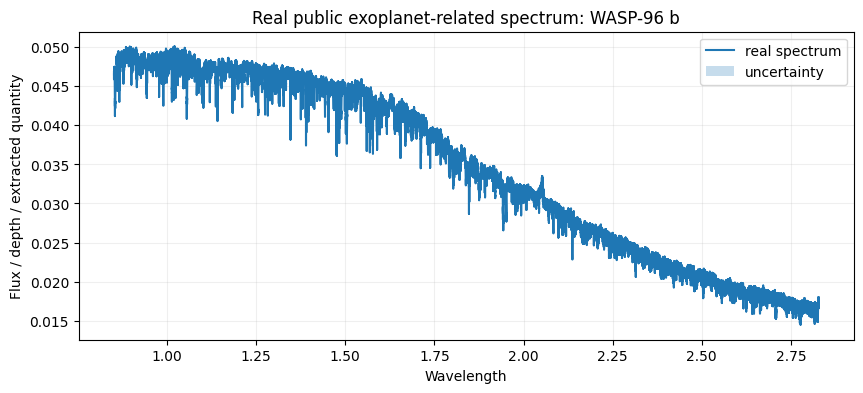

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(wavelength, flux, lw=1.5, label="real spectrum")
if err is not None:
    plt.fill_between(wavelength, flux-err, flux+err, alpha=0.25, label="uncertainty")
plt.xlabel("Wavelength")
plt.ylabel("Flux / depth / extracted quantity")
plt.title(f"Real public exoplanet-related spectrum: {selected_target}")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 2. Host ↔ Device on the real spectrum

This directly mirrors the runtime slide:
- CPU holds the host arrays,
- GPU holds device tensors,
- the main best practice is to transfer once and keep tensors on the GPU.

In [ ]:
wave_cpu = torch.tensor(wavelength, dtype=torch.float32)
flux_cpu = torch.tensor(flux, dtype=torch.float32)
err_cpu = torch.tensor(err, dtype=torch.float32) if err is not None else None

wave_gpu = wave_cpu.to(device)
flux_gpu = flux_cpu.to(device)
err_gpu = err_cpu.to(device) if err_cpu is not None else None

print("CPU tensor device:", flux_cpu.device)
print("GPU tensor device:", flux_gpu.device)
print("Number of bins:", flux_gpu.numel())

CPU tensor device: cpu
GPU tensor device: cuda:0
Number of bins: 187496


## 3. 1D indexing math on a spectrum

For a 1D spectrum, one thread can naturally process one wavelength bin.

\[
i = \text{blockIdx.x}\cdot\text{blockDim.x} + \text{threadIdx.x}
\]

That means thread \(i\) can:
- normalize one bin,
- square one bin,
- compute a residual for one bin,
- apply a mask to one bin.

In [ ]:
def global_index_1d(block_idx, block_dim, thread_idx):
    return block_idx * block_dim + thread_idx

B = 8
for b in range(3):
    ids = [global_index_1d(b, B, t) for t in range(B)]
    print(f"block {b}: {ids}")

block 0: [0, 1, 2, 3, 4, 5, 6, 7]
block 1: [8, 9, 10, 11, 12, 13, 14, 15]
block 2: [16, 17, 18, 19, 20, 21, 22, 23]


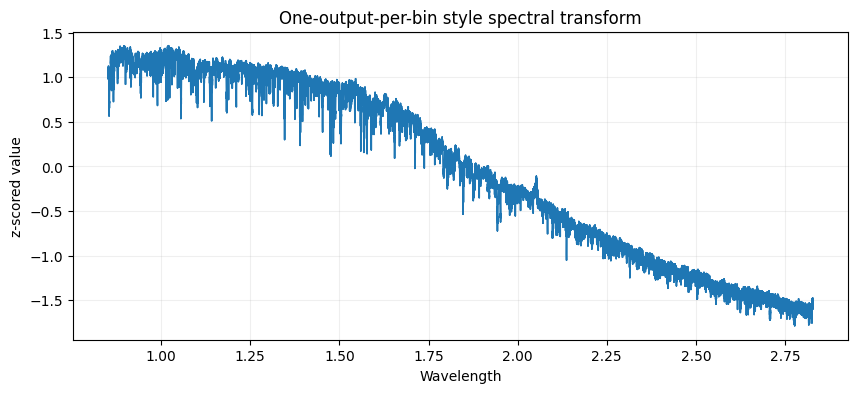

In [ ]:
flux_mean = flux_gpu.mean()
flux_std = flux_gpu.std().clamp_min(1e-12)
flux_z = (flux_gpu - flux_mean) / flux_std

plt.figure(figsize=(10,4))
plt.plot(wavelength, flux_z.detach().cpu().numpy(), lw=1.2)
plt.xlabel("Wavelength")
plt.ylabel("z-scored value")
plt.title("One-output-per-bin style spectral transform")
plt.grid(alpha=0.2)
plt.show()

## 4. 2D / 3D indexing from the same real spectrum

To demonstrate tensor-style mappings:
- **2D**: sliding wavelength windows
- **3D**: a small batch stack of variants of the same real spectrum

2D spectral matrix shape: (46867, 32)


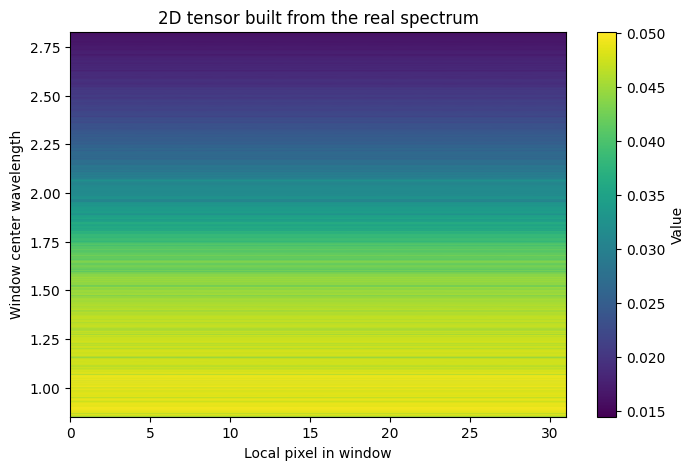

In [ ]:
WINDOW = 32
STRIDE = 4

rows = []
centers = []
for start in range(0, len(flux) - WINDOW + 1, STRIDE):
    rows.append(flux[start:start+WINDOW])
    centers.append(wavelength[start + WINDOW//2])

spec2d = np.stack(rows, axis=0)
centers = np.array(centers)
print("2D spectral matrix shape:", spec2d.shape)

plt.figure(figsize=(8,5))
plt.imshow(spec2d, aspect='auto', origin='lower',
           extent=[0, WINDOW-1, centers.min(), centers.max()])
plt.colorbar(label="Value")
plt.xlabel("Local pixel in window")
plt.ylabel("Window center wavelength")
plt.title("2D tensor built from the real spectrum")
plt.show()

In [ ]:
spec_base = torch.tensor(flux, dtype=torch.float32)
spec_roll = torch.roll(spec_base, shifts=1)
spec_smooth = torch.nn.functional.avg_pool1d(
    spec_base[None, None, :], kernel_size=5, stride=1, padding=2
).squeeze()

spec3d = torch.stack([spec_base, spec_roll, spec_smooth], dim=0)[:, None, :]
print("3D tensor shape [B,C,L]:", tuple(spec3d.shape))

3D tensor shape [B,C,L]: (3, 1, 187496)


## 5. Warp-style divergence intuition on a masked spectral region

A common spectroscopy-style mask:
- one path inside a chosen wavelength window,
- another path outside it.

That mirrors the divergence slide:
different threads may take different branches.

Chosen wavelength window: 1.5230568334098913 1.7224808296924274
branchy spectral mask: mean=0.430 ms | median=0.426 ms | min=0.409 ms
torch.where spectral mask: mean=0.202 ms | median=0.163 ms | min=0.094 ms


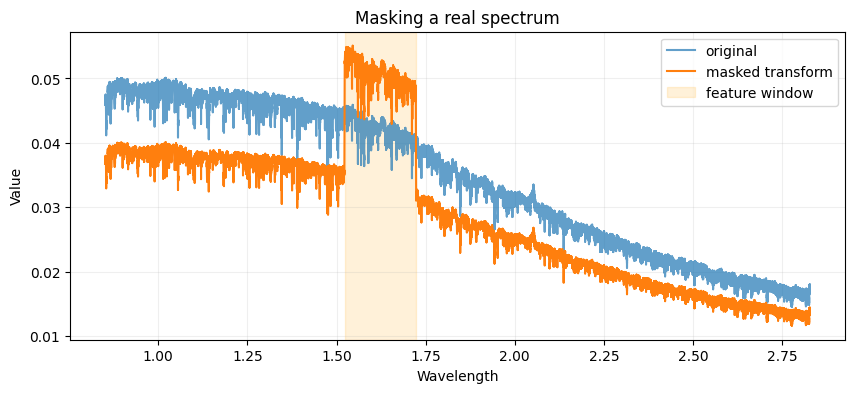

In [ ]:
lo, hi = np.quantile(wavelength, [0.35, 0.45])
print("Chosen wavelength window:", lo, hi)

def branchy_spectral_mask():
    out = torch.empty_like(flux_gpu)
    mask = (wave_gpu >= lo) & (wave_gpu <= hi)
    out[mask] = 1.2 * flux_gpu[mask]
    out[~mask] = 0.8 * flux_gpu[~mask]
    return out

def branch_free_spectral_mask():
    mask = (wave_gpu >= lo) & (wave_gpu <= hi)
    return torch.where(mask, 1.2 * flux_gpu, 0.8 * flux_gpu)

out_branchy, _ = benchmark(branchy_spectral_mask, label="branchy spectral mask")
out_where, _ = benchmark(branch_free_spectral_mask, label="torch.where spectral mask")

plt.figure(figsize=(10,4))
plt.plot(wavelength, flux, label="original", alpha=0.7)
plt.plot(wavelength, out_where.detach().cpu().numpy(), label="masked transform")
plt.axvspan(lo, hi, color="orange", alpha=0.15, label="feature window")
plt.xlabel("Wavelength")
plt.ylabel("Value")
plt.title("Masking a real spectrum")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 6. Reductions on real spectra

The reduction slide emphasized sums, maxima, and norms.

For a real spectrum we can compute:
- total flux-like sum
- mean
- max
- L2 norm
- strongest local window

In [ ]:
total_flux = flux_gpu.sum()
mean_flux = flux_gpu.mean()
max_flux = flux_gpu.max()
l2_norm = torch.linalg.norm(flux_gpu)

print("Total sum :", float(total_flux.cpu()))
print("Mean      :", float(mean_flux.cpu()))
print("Max       :", float(max_flux.cpu()))
print("L2 norm   :", float(l2_norm.cpu()))

Total sum : 6517.6982421875
Mean      : 0.03476179763674736
Max       : 0.05010462552309036
L2 norm   : 15.831531524658203


Most salient local window center: 1.0210686509744398


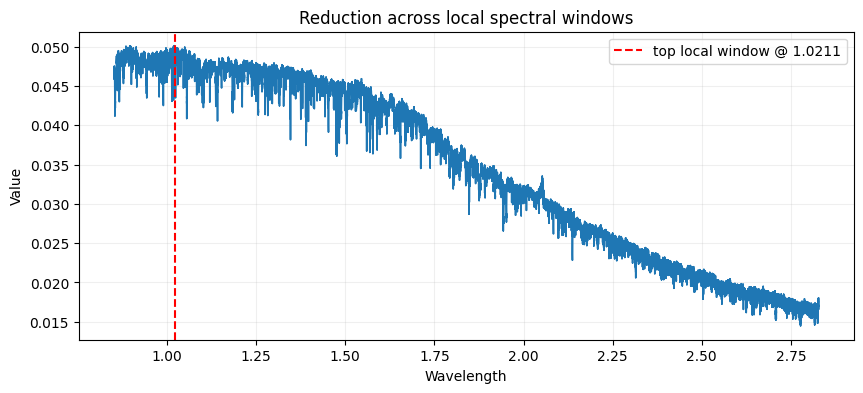

In [ ]:
window_tensor = torch.tensor(spec2d, dtype=torch.float32, device=device)
window_saliency = window_tensor.abs().mean(dim=1)

best_idx = int(window_saliency.argmax().cpu())
best_center = float(centers[best_idx])
print("Most salient local window center:", best_center)

plt.figure(figsize=(10,4))
plt.plot(wavelength, flux, lw=1.2)
plt.axvline(best_center, color="red", ls="--", label=f"top local window @ {best_center:.4f}")
plt.xlabel("Wavelength")
plt.ylabel("Value")
plt.title("Reduction across local spectral windows")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 7. GEMM on real spectra

The GEMM slide says matrix multiplication is the core of deep learning.

We can connect that to a real spectrum by building a polynomial design matrix:
\[
\hat{y} = X a
\]
where the columns of \(X\) are \(1, \lambda, \lambda^2, \lambda^3\).

That turns spectral modeling into a matrix multiplication problem.

Polynomial coefficients: [ 0.03617813 -0.01461267 -0.00146017  0.00197766]


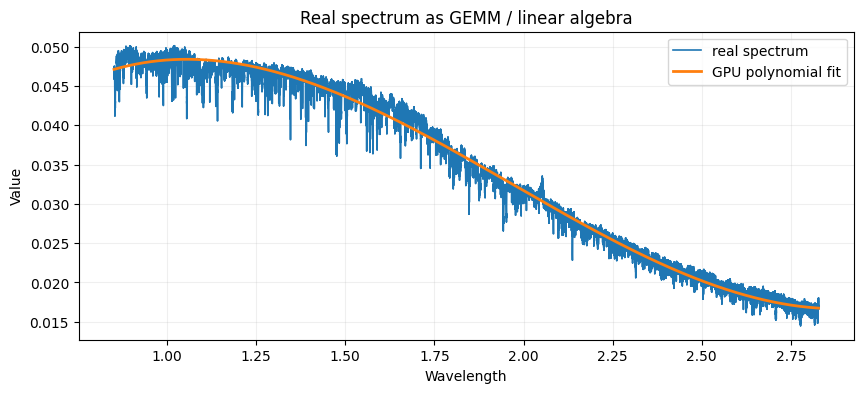

In [ ]:
lam = wave_gpu
lam_n = (lam - lam.mean()) / lam.std().clamp_min(1e-12)

X = torch.stack([
    torch.ones_like(lam_n),
    lam_n,
    lam_n**2,
    lam_n**3
], dim=1)

coef = torch.linalg.lstsq(X, flux_gpu[:, None]).solution.squeeze()
fit = X @ coef

print("Polynomial coefficients:", coef.detach().cpu().numpy())

plt.figure(figsize=(10,4))
plt.plot(wavelength, flux, label="real spectrum", lw=1.2)
plt.plot(wavelength, fit.detach().cpu().numpy(), label="GPU polynomial fit", lw=2)
plt.xlabel("Wavelength")
plt.ylabel("Value")
plt.title("Real spectrum as GEMM / linear algebra")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Arithmetic intensity on a concrete spectral operation

For the elementwise square:
\[
y_i = x_i^2
\]

In FP32:
- read \(x_i\): 4 bytes
- write \(y_i\): 4 bytes
- total bytes \(\approx 8\)
- flops \(\approx 1\)

So:
\[
AI \approx \frac{1}{8} = 0.125 \text{ flop/byte}
\]

That is low, so the operation is usually memory-bound.

In [ ]:
N = flux_gpu.numel()
bytes_per_element = 8
flops_per_element = 1
AI_square = flops_per_element / bytes_per_element

print("Spectrum bins:", N)
print("AI for y=x^2:", AI_square, "flop/byte")

def square_real_spectrum():
    return flux_gpu * flux_gpu

_, square_times = benchmark(square_real_spectrum, label="real-spectrum square")
avg_ms = statistics.mean(square_times)
achieved_bw = (N * bytes_per_element) / (avg_ms * 1e-3) / 1e9
print(f"Approx achieved bandwidth: {achieved_bw:.3f} GB/s")

Spectrum bins: 187496
AI for y=x^2: 0.125 flop/byte
real-spectrum square: mean=0.086 ms | median=0.040 ms | min=0.019 ms
Approx achieved bandwidth: 17.345 GB/s


## 9. Softmax over spectral saliency

This maps the softmax slide to real data:
- compute saliency scores for local windows,
- apply softmax to convert them into a probability distribution over windows.

Stable softmax is:
\[
\text{softmax}(z_i)=\frac{e^{z_i-m}}{\sum_j e^{z_j-m}},\quad m=\max_j z_j
\]

Probability sum: 1.0


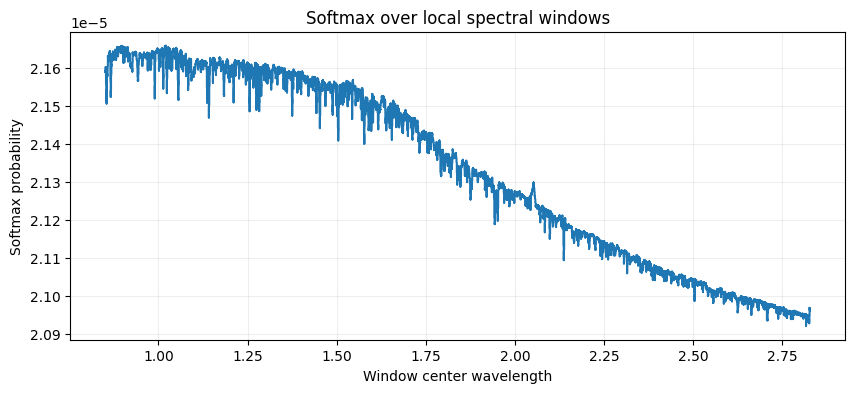

In [ ]:
probs = torch.softmax(window_saliency, dim=0)
print("Probability sum:", float(probs.sum().cpu()))

plt.figure(figsize=(10,4))
plt.plot(centers, probs.detach().cpu().numpy(), lw=1.5)
plt.xlabel("Window center wavelength")
plt.ylabel("Softmax probability")
plt.title("Softmax over local spectral windows")
plt.grid(alpha=0.2)
plt.show()

## 10. Attention over wavelength windows

This directly matches the attention slide.

Treat each local spectral window as a token.
Then compute:
\[
\text{Scores} = \frac{QK^T}{\sqrt{d_k}},\quad
\text{Weights}=\text{softmax}(\text{Scores}),\quad
\text{Out}=\text{Weights}V
\]

This is a didactic bridge from exoplanet spectra to transformer-style computation.

In [ ]:
tokens_full = torch.tensor(spec2d, dtype=torch.float32, device=device)

print("Full token matrix shape:", tuple(tokens_full.shape))

# Conservative cap for Colab GPUs
MAX_TOKENS = 512

if tokens_full.shape[0] > MAX_TOKENS:
    idx = torch.linspace(
        0,
        tokens_full.shape[0] - 1,
        steps=MAX_TOKENS,
        device=device
    ).long()
    tokens = tokens_full[idx]
else:
    tokens = tokens_full

T_tokens, D_in = tokens.shape
D_model = min(32, D_in)
D_value = min(32, D_in)

torch.manual_seed(0)
Wq = torch.randn(D_in, D_model, device=device) / math.sqrt(D_in)
Wk = torch.randn(D_in, D_model, device=device) / math.sqrt(D_in)
Wv = torch.randn(D_in, D_value, device=device) / math.sqrt(D_in)

with torch.no_grad():
    Q = tokens @ Wq
    K = tokens @ Wk
    V = tokens @ Wv
    scores = (Q @ K.transpose(0, 1)) / math.sqrt(D_model)
    weights = torch.softmax(scores, dim=-1)
    attn_out = weights @ V

print("Reduced token matrix shape:", tuple(tokens.shape))
print("Attention matrix shape:", tuple(scores.shape))

Full token matrix shape: (46867, 32)
Reduced token matrix shape: (512, 32)
Attention matrix shape: (512, 512)


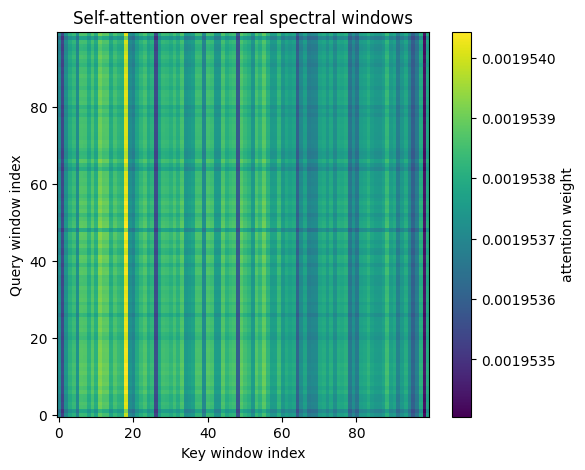

In [ ]:
show_n = min(100, weights.shape[0])
plt.figure(figsize=(6,5))
plt.imshow(weights[:show_n, :show_n].detach().cpu().numpy(), aspect='auto', origin='lower')
plt.colorbar(label="attention weight")
plt.xlabel("Key window index")
plt.ylabel("Query window index")
plt.title("Self-attention over real spectral windows")
plt.show()

## 11. Runtime primer: synchronization and `.item()`

The runtime slide warns that:
- `.item()`
- printing CUDA tensors
- repeated H↔D copies

can force synchronization or waste time.

In [ ]:
def no_item():
    return (tokens @ Wq).sum()

def with_item():
    return (tokens @ Wq).sum().item()

_, t_no = benchmark(no_item, label="sum on GPU, no .item()")
_, t_yes = benchmark(with_item, label="sum on GPU, with .item()")

print("Mean no .item() :", statistics.mean(t_no), "ms")
print("Mean with .item():", statistics.mean(t_yes), "ms")

sum on GPU, no .item(): mean=0.180 ms | median=0.106 ms | min=0.052 ms
sum on GPU, with .item(): mean=0.081 ms | median=0.075 ms | min=0.066 ms
Mean no .item() : 0.1799478499918905 ms
Mean with .item(): 0.08140919999277685 ms


## 12. Profiling workflow in PyTorch

This maps directly to the profiling slide:
- inspect kernels,
- detect memory copies,
- spot synchronization,
- and see whether a pipeline is dominated by a few large ops or many tiny ones.

In [ ]:
if torch.cuda.is_available():
    from torch.profiler import profile, record_function, ProfilerActivity

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True
    ) as prof:
        with record_function("spectral_attention_block"):
            Q = tokens @ Wq
            K = tokens @ Wk
            V = tokens @ Wv
            scores = (Q @ K.transpose(0, 1)) / math.sqrt(D_model)
            weights = torch.softmax(scores, dim=-1)
            out = weights @ V

    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
else:
    print("Profiler is most meaningful on a GPU runtime.")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                               spectral_attention_block         0.00%       0.000us         0.00%       0.000us       0.000us       5.171ms      5089.79%       5.171ms       5.171ms           0 B           0 B           0 B           0 

## 13. First-kernel checklist, grounded in this notebook

### Correctness
- bounds checks for all global accesses
- no inter-block assumptions
- synchronize when sharing block-local data
- validate GPU output against CPU output

### Performance
- start with simple launch choices and measure
- prefer contiguous layouts
- reduce global-memory traffic
- avoid divergence in hot paths
- profile before deciding to go lower-level

In [ ]:
cpu_ref = ((flux_cpu - flux_cpu.mean()) / flux_cpu.std().clamp_min(1e-12)).numpy()
gpu_ref = flux_z.detach().cpu().numpy()
print("Max abs CPU vs GPU difference:", np.max(np.abs(cpu_ref - gpu_ref)))

Max abs CPU vs GPU difference: 3.5762787e-07


## 14. Summary

This real-data notebook supports the main lecture claims:

1. **Indexing math** maps wavelength bins or windows to parallel workers.
2. **Warps and divergence** matter when branch decisions depend on wavelength masks.
3. **Memory traffic** often dominates simple spectral transforms.
4. **GEMM, softmax, and attention** all appear naturally once spectra are treated as tensors.
5. **Profile first** before deciding whether custom CUDA is justified.

That is the main bridge from CUDA lecture slides to real exoplanet spectroscopy workflows.

## 15. Extensions

Good next steps:
- plug in a specific public JWST/HST spectrum you want to study,
- compare contiguous vs non-contiguous spectral tensors,
- add PCA / NMF / convolution over spectral windows,
- replace the toy attention block with a learned model,
- after profiling, re-implement one operation in Triton or a CUDA extension.